# Phase 4: cell-type classification model comparison

This notebook compares supervised models for predicting the reviewed PBMC cell-type labels produced by `04_marker_gene_discovery.ipynb`.

Required models:

- Logistic regression
- Multilayer perceptron (MLP)
- XGBoost
- Stochastic gradient descent (SGD) classifier
- Random forest
- Support vector machine (SVM)

Additional baselines: K-nearest neighbors, Extra Trees, and Multinomial Naive Bayes.

The data are split into stratified 70% training, 20% validation, and 10% test partitions. The final table compares validation and untouched-test accuracy, precision, recall, F1, and multiclass ROC/AUC. Validation macro-F1 selects the model family because the rare platelet class should matter rather than being overwhelmed by large T-cell populations.

## Important interpretation boundary

The target labels were inferred from expression-based Leiden clusters and marker-gene review in notebook 04. They are useful working annotations, but they are **not independent experimental ground truth**. High scores therefore measure how well a model reproduces these annotations, not whether the biological labels are unquestionably correct.

Notebook 02 selected variable genes using all cells, which would leak test-set information into a classifier. This notebook avoids that feature matrix. It starts from all normalized genes stored in `adata.raw`, splits cells first, and fits variance filtering and supervised feature selection only on the 70% training partition inside each model pipeline. Neither validation nor test cells are used to fit these transformations.

## 1. Imports and reproducible settings

SGD is the requested gradient-descent model: it optimizes a linear classifier incrementally with stochastic gradient descent. XGBoost is imported explicitly so a missing dependency fails early with a useful installation instruction.

In [1]:
from pathlib import Path
from time import perf_counter
import json

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
from IPython.display import display
from scipy import sparse
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.feature_selection import SelectKBest, VarianceThreshold, f_classif
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.svm import LinearSVC

try:
    from xgboost import XGBClassifier
except ImportError as error:
    raise ImportError(
        "XGBoost is required. Install PBMC3k/requirements-pbmc3k.txt, then restart the kernel."
    ) from error

RANDOM_STATE = 42
TRAIN_SIZE = 0.70
VALIDATION_SIZE = 0.20
TEST_SIZE = 0.10
CV_FOLDS = 3
N_SELECTED_GENES = 2_000
PRIMARY_METRIC = "f1_macro"

ad.settings.allow_write_nullable_strings = True
sc.set_figure_params(dpi=110, facecolor="white", frameon=False)
sns.set_theme(style="whitegrid", context="notebook")

## 2. Load the reviewed cell-type annotations

Run notebook 04 through its save cell before this notebook. The classifier consumes the annotated Phase 3 object and never invents labels from Leiden numbers.

In [2]:
cwd = Path.cwd().resolve()
candidates = []
for base in (cwd, *cwd.parents):
    candidates.extend((base, base / "PBMC3k", base / "26-the-backpropagators-analysis" / "PBMC3k"))

PROJECT = next(
    (path for path in candidates if (path / "data" / "processed" / "pbmc3k_phase3_annotated.h5ad").is_file()),
    None,
)
if PROJECT is None:
    raise FileNotFoundError(
        "Run 04_marker_gene_discovery.ipynb through its save cell first; expected "
        "PBMC3k/data/processed/pbmc3k_phase3_annotated.h5ad"
    )

INPUT = PROJECT / "data" / "processed" / "pbmc3k_phase3_annotated.h5ad"
TABLES = PROJECT / "results" / "tables"
FIGURES = PROJECT / "results" / "figures"
MODELS = PROJECT / "models"
for directory in (TABLES, FIGURES, MODELS):
    directory.mkdir(parents=True, exist_ok=True)

adata = sc.read_h5ad(INPUT)
required = {
    "reviewed cell types": "cell_type" in adata.obs,
    "all-gene normalized expression": adata.raw is not None,
}
display(pd.Series(required, name="available").to_frame())
if not all(required.values()):
    raise ValueError("The Phase 3 object must contain adata.obs['cell_type'] and adata.raw.")

print(adata)
print("Input:", INPUT)

,available
reviewed cell types,True
all-gene normalized expression,True


AnnData object with n_obs × n_vars = 2638 × 2000
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'pass_min_genes', 'pass_max_genes', 'pass_mt', 'pass_qc', 'kmeans', 'leiden_0_3', 'leiden_0_4', 'leiden_0_5', 'leiden_0_6', 'leiden_0_7', 'leiden_0_8', 'leiden', 'cell_type', 'annotation_confidence'
    var: 'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'expression_mean', 'expression_std', 'std_rank', 'selected_by_std', 'mean', 'std'
    uns: '_leiden_repeat_168', '_leiden_repeat_21', '_leiden_repeat_42', '_leiden_repeat_7', '_leiden_repeat_84', 'cell_type_annotation', 'cell_type_colors', 'dendrogram_leiden', 'kmeans_colors', 'kmeans_model_selection', 'leiden', 'leiden_0_3', 'leiden_0_4', 'leiden_0_5', 'leiden_0_6', 'leiden_0_7', 'leiden_0_8', 'leiden_colors', 'leiden_model_selection', 'log1p', 'neighbors', 'pca', 'rank_genes_groups', 'rank_genes_groups_leiden', 'umap'
    obsm: 'X_pca', 'X_tsne', 

## 3. Prepare labels and inspect class balance

The expression matrix contains normalized `log1p` values for all retained genes. Labels are encoded as integers only for model compatibility; the mapping is retained for reports and plots.

,cells,percent
cell_type,,
IL7R+ memory/helper T cells,602,22.8%
Classical monocytes,502,19.0%
Naive/resting T cells,450,17.1%
B cells,348,13.2%
Cytotoxic CD8 T cells,273,10.3%
CD16+ non-classical monocytes,171,6.5%
NK cells,153,5.8%
Activated/transitional T cells,128,4.9%
Platelets,11,0.4%


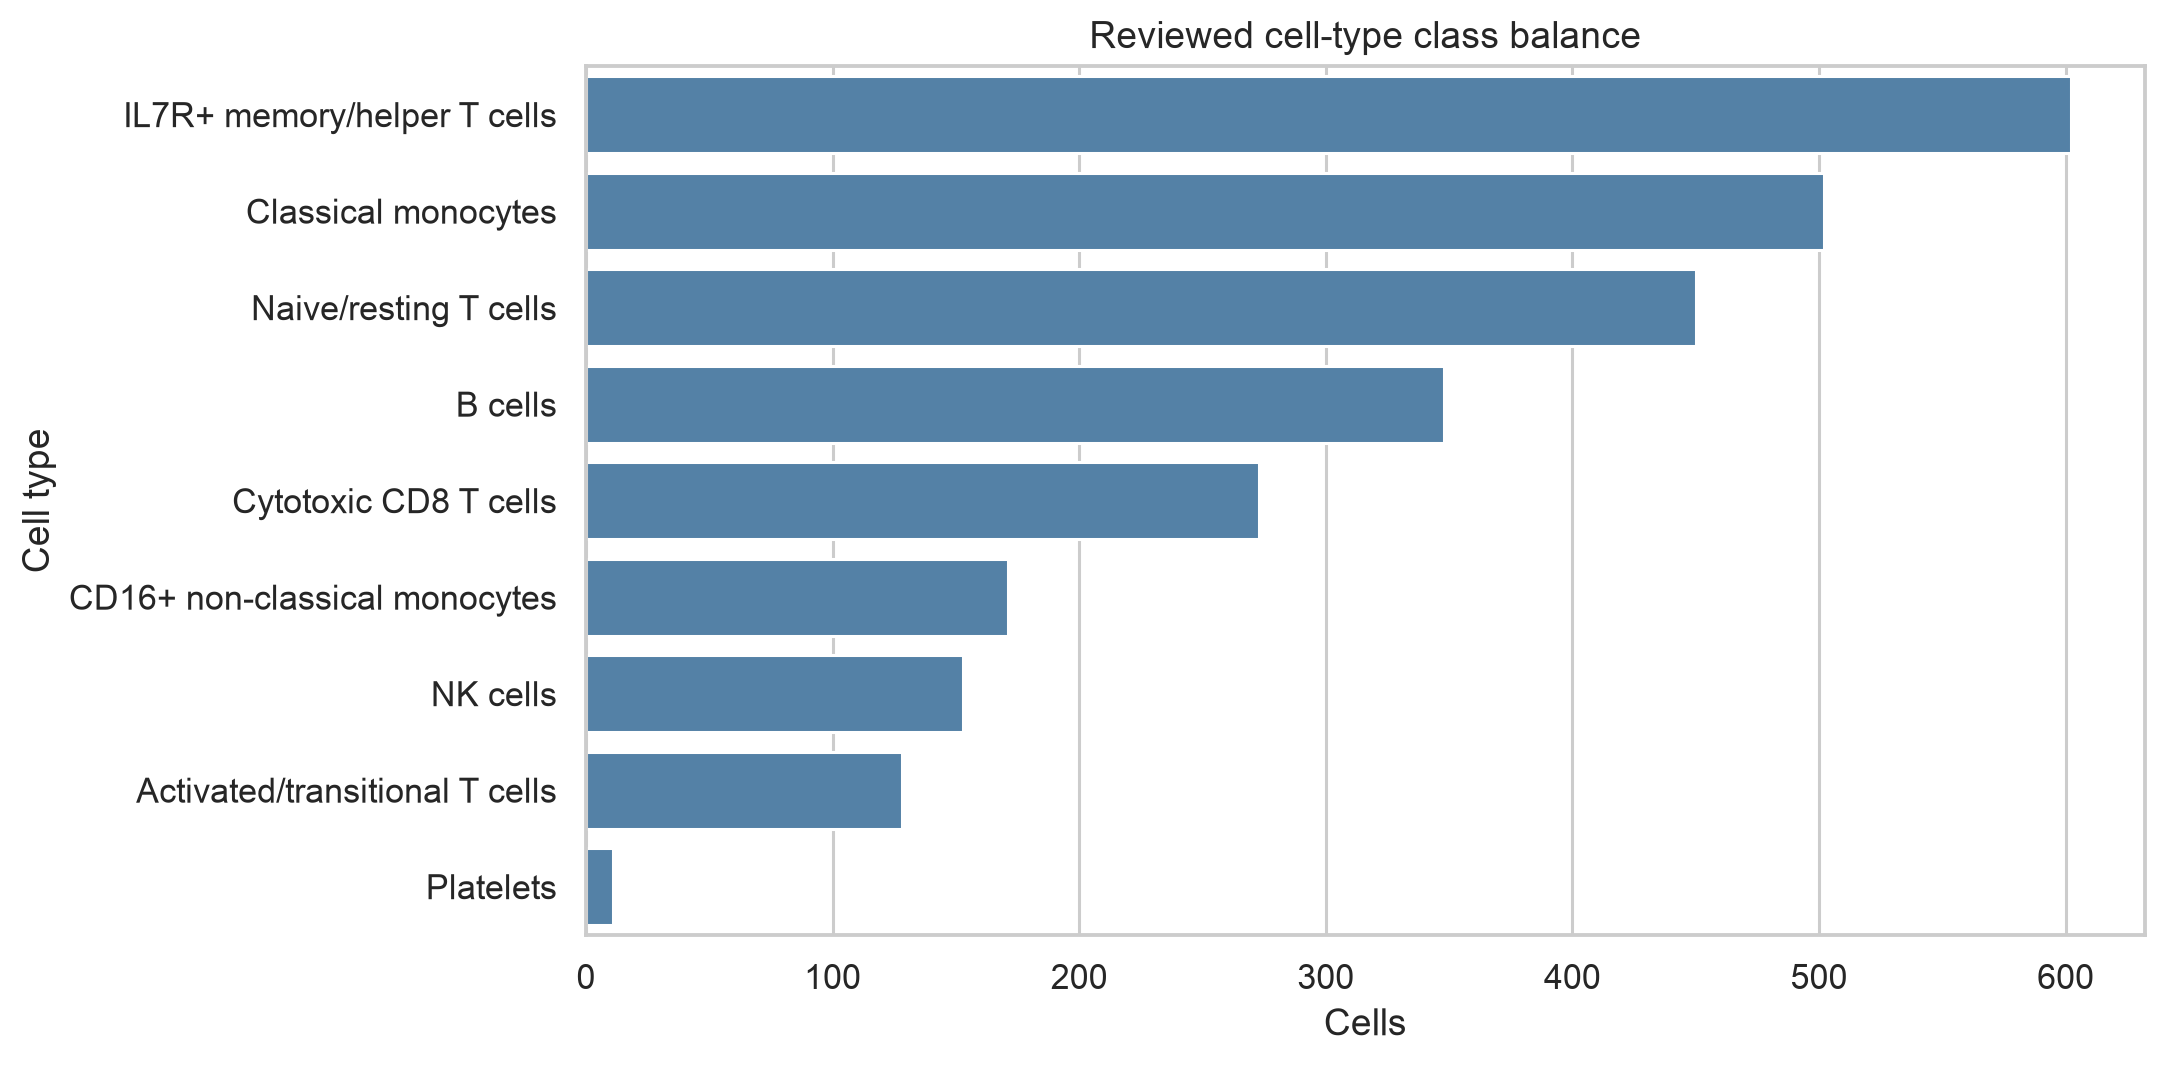

Expression matrix: 2,638 cells × 13,656 genes
Label mapping: {0: 'Activated/transitional T cells', 1: 'B cells', 2: 'CD16+ non-classical monocytes', 3: 'Classical monocytes', 4: 'Cytotoxic CD8 T cells', 5: 'IL7R+ memory/helper T cells', 6: 'NK cells', 7: 'Naive/resting T cells', 8: 'Platelets'}


In [3]:
X = adata.raw.X.astype(np.float64).copy()
if not sparse.issparse(X):
    X = sparse.csr_matrix(X)
else:
    X = X.tocsr()

gene_names = np.asarray(adata.raw.var_names)
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(adata.obs["cell_type"].astype(str))
class_names = label_encoder.classes_

class_counts = pd.Series(adata.obs["cell_type"].astype(str)).value_counts().sort_values(ascending=False)
class_balance = class_counts.rename("cells").to_frame()
class_balance["percent"] = 100 * class_balance["cells"] / len(y)
display(class_balance.style.format({"percent": "{:.1f}%"}))

plt.figure(figsize=(10, 5))
sns.barplot(data=class_balance.reset_index(), y="cell_type", x="cells", color="steelblue")
plt.title("Reviewed cell-type class balance")
plt.xlabel("Cells")
plt.ylabel("Cell type")
plt.tight_layout()
plt.show()

print(f"Expression matrix: {X.shape[0]:,} cells × {X.shape[1]:,} genes")
print("Label mapping:", dict(enumerate(class_names)))

## 4. Create stratified 70% training, 20% validation, and 10% test sets

Every model receives exactly the same partitions. The first split reserves the untouched 10% test set; the second splits the remaining cells so validation is 20% of the full dataset and training is 70%. Stratification preserves rare classes as far as integer sample counts permit. Only training cells fit feature selection, scaling, and hyperparameters. Validation macro-F1 chooses the model family, and test cells are used only for final reporting.

In [4]:
indices = np.arange(adata.n_obs)
development_idx, test_idx = train_test_split(
    indices,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE,
)
validation_fraction_of_development = VALIDATION_SIZE / (TRAIN_SIZE + VALIDATION_SIZE)
train_idx, validation_idx = train_test_split(
    development_idx,
    test_size=validation_fraction_of_development,
    stratify=y[development_idx],
    random_state=RANDOM_STATE,
)

X_train, X_validation, X_test = X[train_idx], X[validation_idx], X[test_idx]
y_train, y_validation, y_test = y[train_idx], y[validation_idx], y[test_idx]

split_balance = pd.DataFrame({
    "all": np.bincount(y, minlength=len(class_names)),
    "train": np.bincount(y_train, minlength=len(class_names)),
    "validation": np.bincount(y_validation, minlength=len(class_names)),
    "test": np.bincount(y_test, minlength=len(class_names)),
}, index=class_names)
display(split_balance)

split_summary = pd.DataFrame({
    "cells": [len(train_idx), len(validation_idx), len(test_idx)],
    "percent": 100 * np.array([len(train_idx), len(validation_idx), len(test_idx)]) / len(indices),
}, index=["train", "validation", "test"])
display(split_summary.style.format({"percent": "{:.2f}%"}))

assert len(set(train_idx) & set(validation_idx)) == 0
assert len(set(train_idx) & set(test_idx)) == 0
assert len(set(validation_idx) & set(test_idx)) == 0
assert len(train_idx) + len(validation_idx) + len(test_idx) == len(indices)

minimum_training_class = int(split_balance["train"].min())
if minimum_training_class < CV_FOLDS:
    raise ValueError(
        f"The smallest training class has {minimum_training_class} cells, "
        f"which is insufficient for {CV_FOLDS}-fold stratified CV."
    )
print(
    f"Training cells: {len(train_idx):,}; validation cells: {len(validation_idx):,}; "
    f"untouched test cells: {len(test_idx):,}"
)

,all,train,validation,test
Activated/transitional T cells,128,89,26,13
B cells,348,243,70,35
CD16+ non-classical monocytes,171,120,34,17
Classical monocytes,502,352,100,50
Cytotoxic CD8 T cells,273,191,54,28
IL7R+ memory/helper T cells,602,421,121,60
NK cells,153,107,31,15
Naive/resting T cells,450,315,90,45
Platelets,11,8,2,1


,cells,percent
train,1846,69.98%
validation,528,20.02%
test,264,10.01%


Training cells: 1,846; validation cells: 528; untouched test cells: 264


## 5. Define leakage-safe model pipelines

Every pipeline removes constant genes and selects up to 2,000 informative genes using the 70% training labels only. Linear, neural-network, SVM, and KNN models additionally standardize features. Tree and Naive Bayes models retain nonnegative normalized expression without scaling.

The parameter grids are intentionally compact: they give each method meaningful tuning without turning this educational comparison into an hours-long exhaustive search.

In [5]:
def make_pipeline(classifier, scale=False):
    steps = [
        ("variance", VarianceThreshold()),
        ("select", SelectKBest(score_func=f_classif, k=min(N_SELECTED_GENES, X_train.shape[1]))),
    ]
    if scale:
        steps.append(("scale", StandardScaler(with_mean=False)))
    steps.append(("classifier", classifier))
    return Pipeline(steps)

model_specs = {
    "Logistic regression": {
        "pipeline": make_pipeline(
            LogisticRegression(max_iter=2_000, class_weight="balanced", solver="lbfgs", random_state=RANDOM_STATE),
            scale=True,
        ),
        "grid": {"classifier__C": [0.1, 1.0, 10.0]},
    },
    "MLP": {
        "pipeline": make_pipeline(
            MLPClassifier(max_iter=500, early_stopping=True, validation_fraction=0.15, random_state=RANDOM_STATE),
            scale=True,
        ),
        "grid": {"classifier__hidden_layer_sizes": [(64,), (128,), (64, 32)], "classifier__alpha": [0.0001, 0.001]},
    },
    "XGBoost": {
        "pipeline": make_pipeline(
            XGBClassifier(
                objective="multi:softprob", eval_metric="mlogloss", n_estimators=250,
                subsample=0.8, colsample_bytree=0.8, tree_method="hist",
                random_state=RANDOM_STATE, n_jobs=1,
            )
        ),
        "grid": {"classifier__max_depth": [3, 6], "classifier__learning_rate": [0.05, 0.1]},
    },
    "SGD (gradient descent)": {
        "pipeline": make_pipeline(
            SGDClassifier(max_iter=3_000, tol=1e-4, class_weight="balanced", random_state=RANDOM_STATE),
            scale=True,
        ),
        "grid": {"classifier__loss": ["log_loss", "modified_huber"], "classifier__alpha": [1e-5, 1e-4, 1e-3]},
    },
    "Random forest": {
        "pipeline": make_pipeline(
            RandomForestClassifier(n_estimators=400, class_weight="balanced_subsample", random_state=RANDOM_STATE, n_jobs=1)
        ),
        "grid": {"classifier__max_depth": [None, 20], "classifier__min_samples_leaf": [1, 2]},
    },
    "Support vector machine": {
        "pipeline": make_pipeline(
            LinearSVC(
                class_weight="balanced",
                max_iter=5_000,
                dual="auto",
                random_state=RANDOM_STATE,
            ),
            scale=True,
        ),
        "grid": {"classifier__C": [0.01, 0.1, 1.0, 10.0]},
    },
    "K-nearest neighbors": {
        "pipeline": make_pipeline(KNeighborsClassifier(weights="distance"), scale=True),
        "grid": {"classifier__n_neighbors": [5, 11, 21]},
    },
    "Extra Trees": {
        "pipeline": make_pipeline(
            ExtraTreesClassifier(n_estimators=400, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=1)
        ),
        "grid": {"classifier__max_features": ["sqrt", 0.25], "classifier__min_samples_leaf": [1, 2]},
    },
    "Multinomial Naive Bayes": {
        "pipeline": make_pipeline(MultinomialNB()),
        "grid": {"classifier__alpha": [0.1, 1.0, 10.0]},
    },
}

model_inventory = pd.DataFrame({
    "model": model_specs.keys(),
    "candidate_settings": [int(np.prod([len(values) for values in spec["grid"].values()])) for spec in model_specs.values()],
}).set_index("model")
display(model_inventory)

,candidate_settings
model,
Logistic regression,3
MLP,6
XGBoost,4
SGD (gradient descent),6
Random forest,4
Support vector machine,4
K-nearest neighbors,3
Extra Trees,4
Multinomial Naive Bayes,3


## 6. Tune on training, select with validation, and evaluate on test

Grid search uses stratified three-fold cross-validation entirely within the 70% training partition to select each model's hyperparameters. The fitted candidate is scored on the 20% validation partition, and validation macro-F1 selects the best model family. The 10% test partition is evaluated only after fitting and model selection decisions are fixed. Precision, recall, and F1 are reported with both macro and weighted averaging.

ROC/AUC uses one-vs-rest multiclass weighting. Most estimators provide class probabilities; the linear SVM provides signed decision scores, which ROC/AUC can use directly.

In [6]:
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
results = []
fitted_models = {}
validation_predictions = {}
test_predictions = {}
y_validation_binary = label_binarize(y_validation, classes=np.arange(len(class_names)))
y_test_binary = label_binarize(y_test, classes=np.arange(len(class_names)))


def score_partition(y_true, predictions, score_matrix, prefix):
    y_binary = label_binarize(y_true, classes=np.arange(len(class_names)))
    return {
        f"{prefix}_accuracy": accuracy_score(y_true, predictions),
        f"{prefix}_balanced_accuracy": balanced_accuracy_score(y_true, predictions),
        f"{prefix}_precision": precision_score(y_true, predictions, average="weighted", zero_division=0),
        f"{prefix}_recall": recall_score(y_true, predictions, average="weighted", zero_division=0),
        f"{prefix}_f1_score": f1_score(y_true, predictions, average="weighted", zero_division=0),
        f"{prefix}_macro_precision": precision_score(y_true, predictions, average="macro", zero_division=0),
        f"{prefix}_macro_recall": recall_score(y_true, predictions, average="macro", zero_division=0),
        f"{prefix}_macro_f1": f1_score(y_true, predictions, average="macro", zero_division=0),
        f"{prefix}_roc_auc_ovr_weighted": roc_auc_score(y_binary, score_matrix, average="weighted"),
        f"{prefix}_roc_auc_ovr_macro": roc_auc_score(y_binary, score_matrix, average="macro"),
    }


for model_name, spec in model_specs.items():
    print(f"\nTraining {model_name}...")
    started = perf_counter()
    search = GridSearchCV(
        estimator=spec["pipeline"],
        param_grid=spec["grid"],
        scoring=PRIMARY_METRIC,
        cv=cv,
        n_jobs=-1,
        refit=True,
        return_train_score=False,
        error_score="raise",
    )
    search.fit(X_train, y_train)
    elapsed = perf_counter() - started

    best_model = search.best_estimator_
    validation_prediction = best_model.predict(X_validation)
    test_prediction = best_model.predict(X_test)
    if hasattr(best_model, "predict_proba"):
        validation_score_matrix = best_model.predict_proba(X_validation)
        test_score_matrix = best_model.predict_proba(X_test)
    else:
        validation_score_matrix = best_model.decision_function(X_validation)
        test_score_matrix = best_model.decision_function(X_test)

    fitted_models[model_name] = best_model
    validation_predictions[model_name] = validation_prediction
    test_predictions[model_name] = test_prediction
    row = {
        "model": model_name,
        "training_cv_macro_f1_mean": search.best_score_,
        "training_cv_macro_f1_std": search.cv_results_["std_test_score"][search.best_index_],
        "fit_seconds": elapsed,
        "best_parameters": json.dumps(search.best_params_, sort_keys=True),
    }
    row.update(score_partition(y_validation, validation_prediction, validation_score_matrix, "validation"))
    row.update(score_partition(y_test, test_prediction, test_score_matrix, "test"))
    results.append(row)
    print(
        f"Training CV macro-F1: {search.best_score_:.3f}; "
        f"validation macro-F1: {row['validation_macro_f1']:.3f}; "
        f"test macro-F1: {row['test_macro_f1']:.3f}"
    )

results_table = (
    pd.DataFrame(results)
    .sort_values(
        ["validation_macro_f1", "validation_roc_auc_ovr_macro", "training_cv_macro_f1_mean"],
        ascending=False,
    )
    .reset_index(drop=True)
)
results_table.index = np.arange(1, len(results_table) + 1)
results_table.index.name = "rank"

headline_columns = [
    "model",
    "validation_accuracy", "validation_precision", "validation_recall",
    "validation_f1_score", "validation_macro_f1", "validation_roc_auc_ovr_weighted",
    "test_accuracy", "test_precision", "test_recall",
    "test_f1_score", "test_macro_f1", "test_roc_auc_ovr_weighted",
]
detail_columns = [
    "model", "validation_balanced_accuracy", "validation_macro_precision",
    "validation_macro_recall", "validation_roc_auc_ovr_macro",
    "test_balanced_accuracy", "test_macro_precision", "test_macro_recall",
    "test_roc_auc_ovr_macro", "training_cv_macro_f1_mean",
    "training_cv_macro_f1_std", "fit_seconds", "best_parameters",
]
display(results_table[headline_columns].style.format({
    column: "{:.3f}" for column in headline_columns if column != "model"
}))
display(results_table[detail_columns].style.format({
    column: "{:.3f}" for column in detail_columns if column not in ["model", "best_parameters", "fit_seconds"]
}).format({"fit_seconds": "{:.1f}"}))



Training Logistic regression...


Training CV macro-F1: 0.897; validation macro-F1: 0.915; test macro-F1: 0.934

Training MLP...


/Users/brianqian/Desktop/cosmos/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/brianqian/Desktop/cosmos/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/brianqian/Desktop/cosmos/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/brianqian/Desktop/cosmos/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/brianqian/Desktop/cosmos/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/brianqian/Desktop/cosmos/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/brianqian/Desktop/cosmo

/Users/brianqian/Desktop/cosmos/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/brianqian/Desktop/cosmos/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/brianqian/Desktop/cosmos/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/brianqian/Desktop/cosmos/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/brianqian/Desktop/cosmos/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/brianqian/Desktop/cosmos/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/brianqian/Desktop/cosmo

/Users/brianqian/Desktop/cosmos/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/brianqian/Desktop/cosmos/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/brianqian/Desktop/cosmos/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/brianqian/Desktop/cosmos/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/brianqian/Desktop/cosmos/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/brianqian/Desktop/cosmos/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/brianqian/Desktop/cosmo

...

Training CV macro-F1: 0.303; validation macro-F1: 0.391; test macro-F1: 0.302

Training Extra Trees...


Training CV macro-F1: 0.885; validation macro-F1: 0.892; test macro-F1: 0.892

Training Multinomial Naive Bayes...


Training CV macro-F1: 0.863; validation macro-F1: 0.891; test macro-F1: 0.895


,model,validation_accuracy,validation_precision,validation_recall,validation_f1_score,validation_macro_f1,validation_roc_auc_ovr_weighted,test_accuracy,test_precision,test_recall,test_f1_score,test_macro_f1,test_roc_auc_ovr_weighted
rank,,,,,,,,,,,,,
1,XGBoost,0.928,0.931,0.928,0.927,0.928,0.993,0.902,0.901,0.902,0.900,0.893,0.991
2,SGD (gradient descent),0.932,0.934,0.932,0.930,0.923,0.993,0.932,0.935,0.932,0.930,0.928,0.992
3,Logistic regression,0.926,0.928,0.926,0.924,0.915,0.995,0.932,0.935,0.932,0.931,0.934,0.994
4,Support vector machine,0.913,0.915,0.913,0.910,0.901,0.988,0.909,0.910,0.909,0.906,0.907,0.986
5,Extra Trees,0.907,0.913,0.907,0.902,0.892,0.992,0.905,0.913,0.905,0.901,0.892,0.993
6,Multinomial Naive Bayes,0.919,0.924,0.919,0.910,0.891,0.993,0.913,0.919,0.913,0.906,0.895,0.992
7,MLP,0.902,0.903,0.902,0.896,0.882,0.991,0.902,0.902,0.902,0.897,0.885,0.989
8,Random forest,0.911,0.918,0.911,0.898,0.869,0.993,0.890,0.903,0.890,0.875,0.848,0.991
9,K-nearest neighbors,0.455,0.624,0.455,0.399,0.391,0.782,0.443,0.581,0.443,0.367,0.302,0.766


,model,validation_balanced_accuracy,validation_macro_precision,validation_macro_recall,validation_roc_auc_ovr_macro,test_balanced_accuracy,test_macro_precision,test_macro_recall,test_roc_auc_ovr_macro,training_cv_macro_f1_mean,training_cv_macro_f1_std,fit_seconds,best_parameters
rank,,,,,,,,,,,,,
1,XGBoost,0.914696,0.951711,0.914696,0.994732,0.890235,0.897809,0.890235,0.990514,0.889985,0.016869,74.3,"{""classifier__learning_rate"": 0.1, ""classifier__max_depth"": 6}"
2,SGD (gradient descent),0.908932,0.948695,0.908932,0.993636,0.915984,0.949887,0.915984,0.990817,0.881912,0.019212,7.9,"{""classifier__alpha"": 0.0001, ""classifier__loss"": ""log_loss""}"
3,Logistic regression,0.899321,0.943953,0.899321,0.995965,0.924090,0.950499,0.924090,0.993212,0.896733,0.006980,2.9,"{""classifier__C"": 0.1}"
4,Support vector machine,0.883707,0.936379,0.883707,0.989904,0.898883,0.928131,0.898883,0.987170,0.866463,0.006842,0.9,"{""classifier__C"": 0.01}"
5,Extra Trees,0.873102,0.943278,0.873102,0.993946,0.866310,0.948371,0.866310,0.993853,0.884999,0.008555,17.8,"{""classifier__max_features"": ""sqrt"", ""classifier__min_samples_leaf"": 2}"
6,Multinomial Naive Bayes,0.880909,0.948631,0.880909,0.993138,0.888050,0.944336,0.888050,0.991188,0.862746,0.003918,0.2,"{""classifier__alpha"": 1.0}"
7,MLP,0.869218,0.918663,0.869218,0.990868,0.874601,0.915586,0.874601,0.987517,0.835878,0.003829,3.2,"{""classifier__alpha"": 0.0001, ""classifier__hidden_layer_sizes"": [128]}"
8,Random forest,0.862980,0.947201,0.862980,0.994822,0.845916,0.941290,0.845916,0.991405,0.825894,0.001785,8.7,"{""classifier__max_depth"": 20, ""classifier__min_samples_leaf"": 2}"
9,K-nearest neighbors,0.383597,0.686317,0.383597,0.756823,0.313117,0.542179,0.313117,0.780581,0.303474,0.013386,0.4,"{""classifier__n_neighbors"": 5}"


## 7. Compare models visually and select the best

The winner is the model with the highest macro-F1 on the 20% validation partition. Training-only cross-validation selects hyperparameters within each family; the validation set compares model families. Test metrics are final estimates and do not affect the ranking. This deliberately values every cell type equally. Review the test per-class report before accepting the winner: a model can have excellent overall accuracy while failing on the very small platelet population.


Selected best model by validation macro-F1: XGBoost


,model,validation_accuracy,validation_precision,validation_recall,validation_f1_score,validation_macro_f1,validation_roc_auc_ovr_weighted,test_accuracy,test_precision,test_recall,test_f1_score,test_macro_f1,test_roc_auc_ovr_weighted,training_cv_macro_f1_mean,best_parameters
rank,,,,,,,,,,,,,,,
1,XGBoost,0.92803,0.931142,0.92803,0.9267,0.927699,0.99344,0.901515,0.900845,0.901515,0.900256,0.893105,0.991098,0.889985,"{""classifier__learning_rate"": 0.1, ""classifier..."


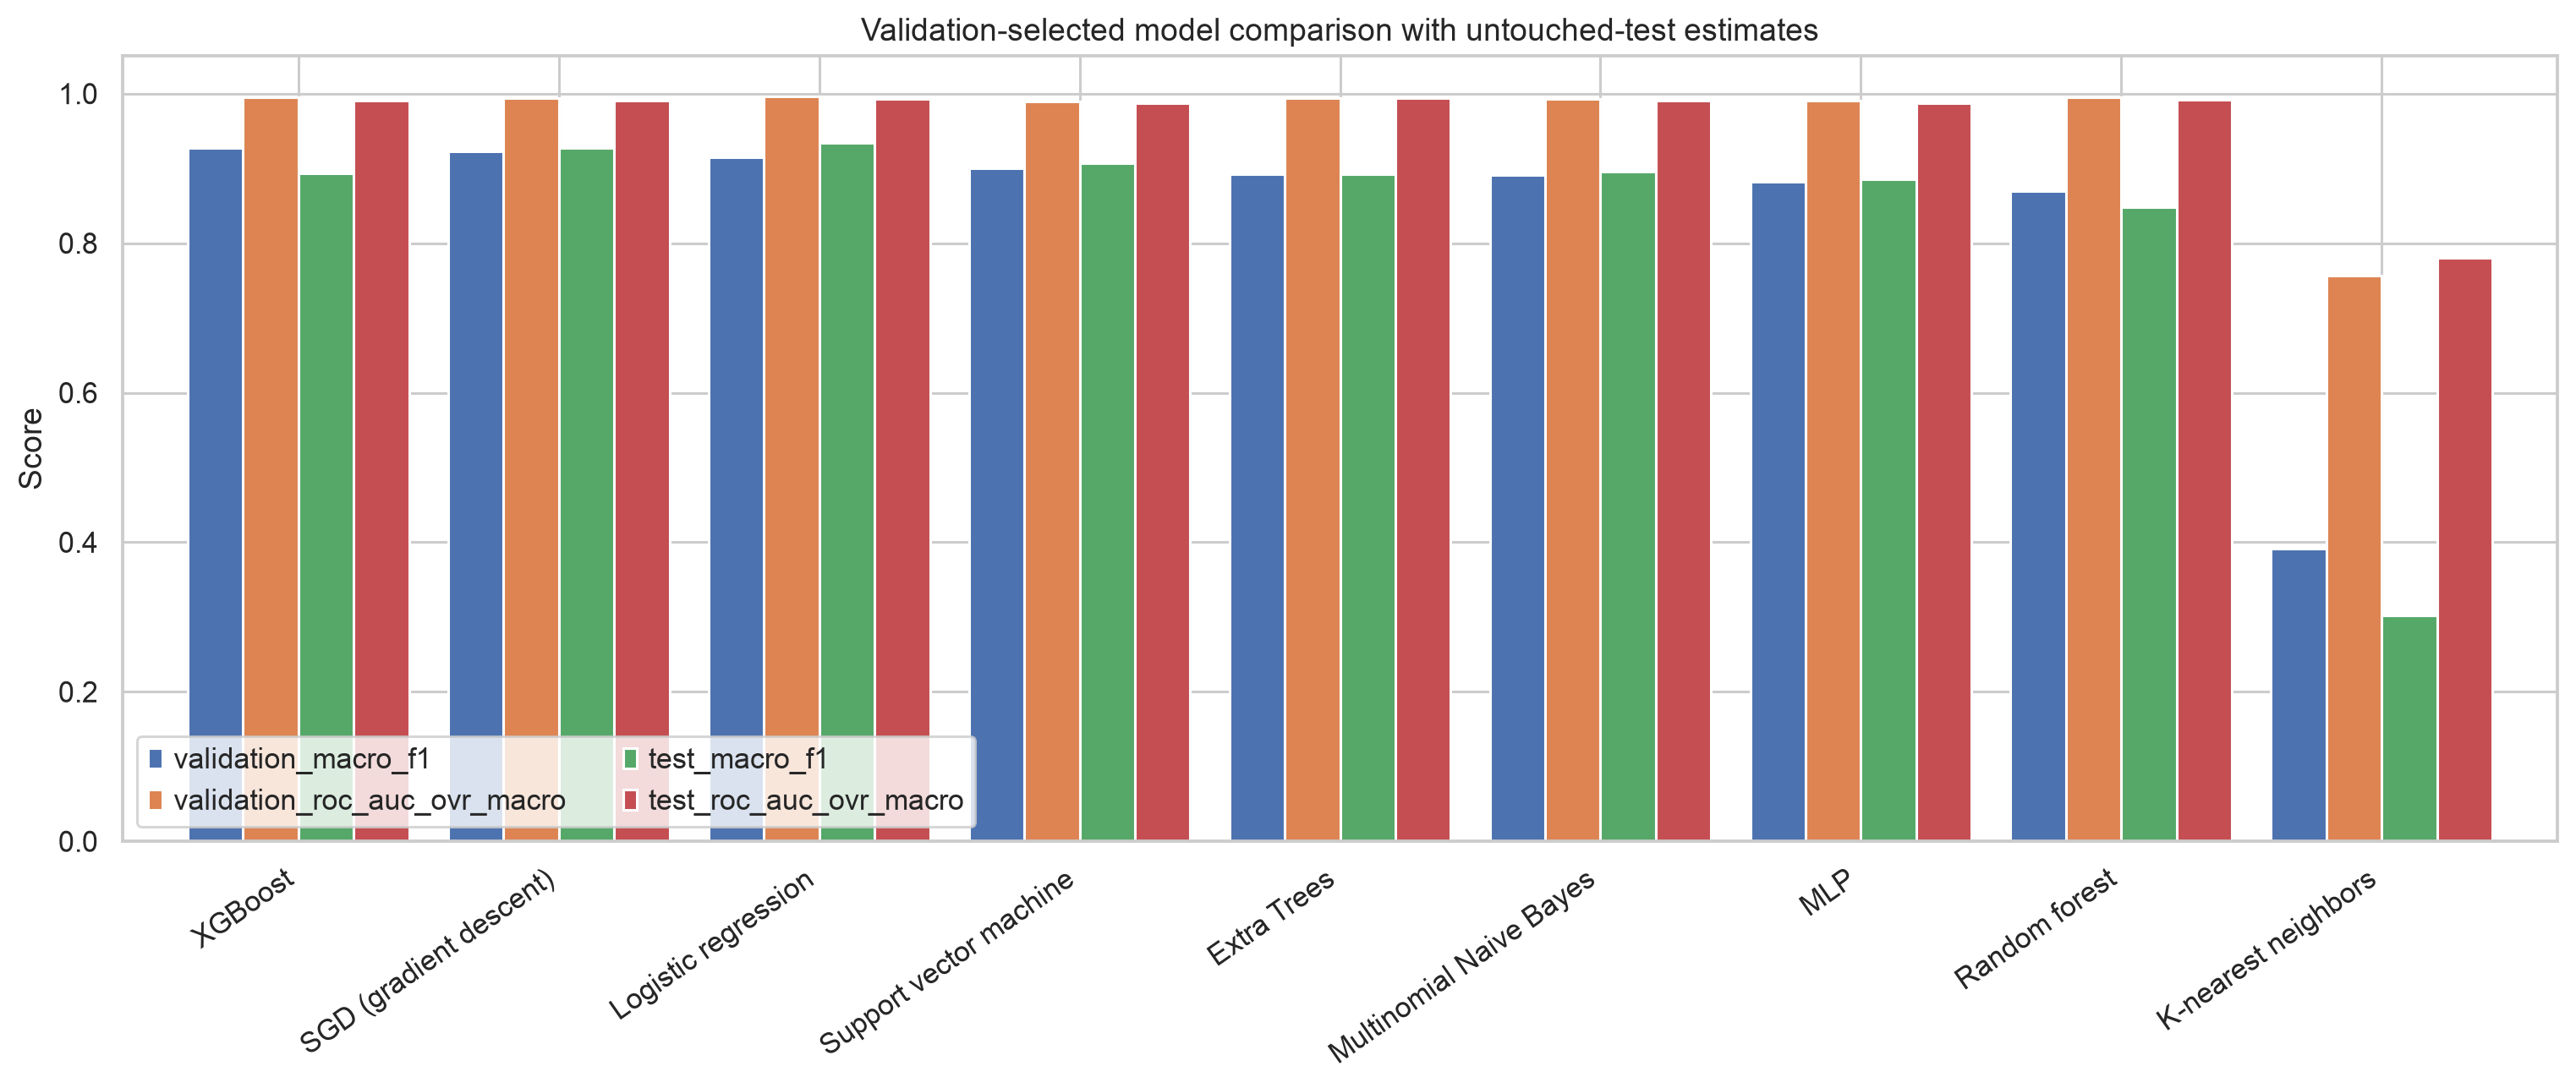

,precision,recall,f1-score,support
Activated/transitional T cells,0.636,0.538,0.583,13.000
B cells,1.000,1.000,1.000,35.000
CD16+ non-classical monocytes,0.944,1.000,0.971,17.000
Classical monocytes,1.000,0.980,0.990,50.000
Cytotoxic CD8 T cells,0.852,0.821,0.836,28.000
IL7R+ memory/helper T cells,0.833,0.917,0.873,60.000
NK cells,0.933,0.933,0.933,15.000
Naive/resting T cells,0.881,0.822,0.851,45.000
Platelets,1.000,1.000,1.000,1.000
accuracy,0.902,0.902,0.902,0.902


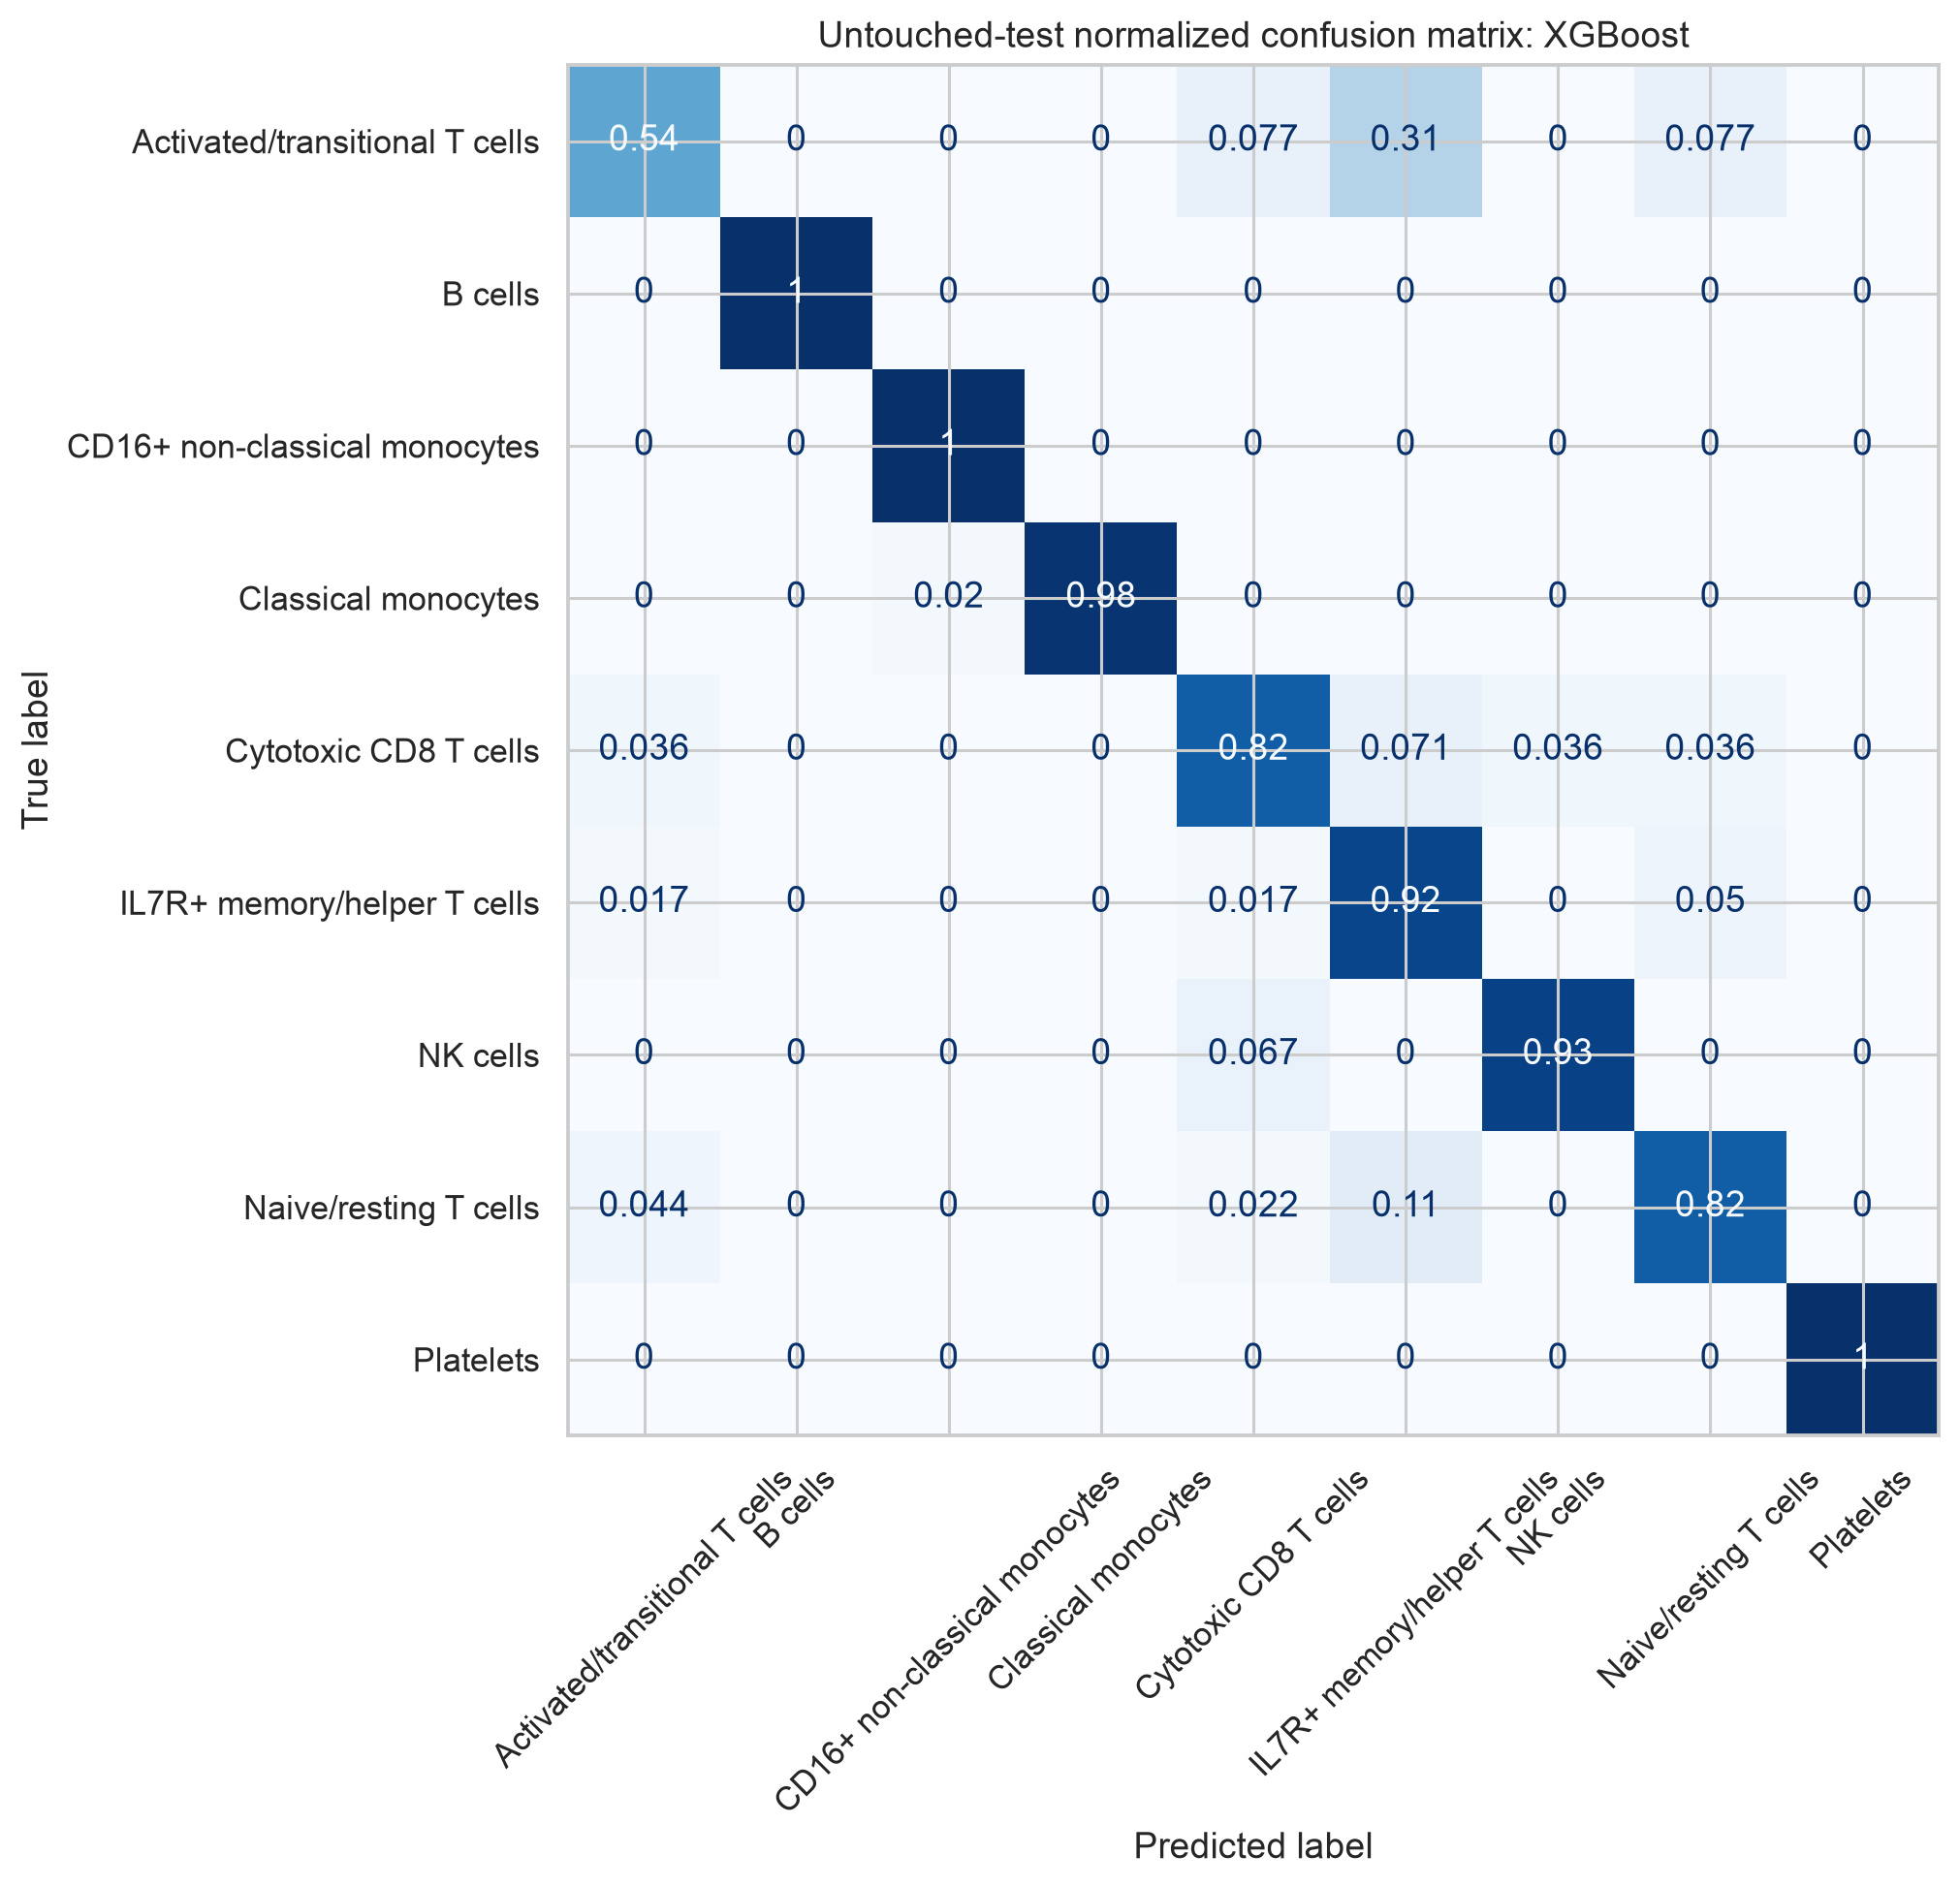

In [7]:
best_model_name = results_table.iloc[0]["model"]
best_model = fitted_models[best_model_name]
best_predictions = test_predictions[best_model_name]

print(f"Selected best model by validation macro-F1: {best_model_name}")
display(results_table.iloc[[0]][headline_columns + [
    "training_cv_macro_f1_mean", "best_parameters"
]])

plot_metrics = results_table.set_index("model")[[
    "validation_macro_f1", "validation_roc_auc_ovr_macro",
    "test_macro_f1", "test_roc_auc_ovr_macro",
]]
plot_metrics.plot.bar(figsize=(14, 6), ylim=(0, 1.05), width=0.85)
plt.title("Validation-selected model comparison with untouched-test estimates")
plt.ylabel("Score")
plt.xlabel("")
plt.xticks(rotation=35, ha="right")
plt.legend(loc="lower left", ncol=2)
plt.tight_layout()
plt.show()

report = pd.DataFrame(
    classification_report(
        y_test,
        best_predictions,
        labels=np.arange(len(class_names)),
        target_names=class_names,
        output_dict=True,
        zero_division=0,
    )
).T
display(report.round(3))

fig, axis = plt.subplots(figsize=(10, 9))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_predictions,
    labels=np.arange(len(class_names)),
    display_labels=class_names,
    normalize="true",
    xticks_rotation=45,
    cmap="Blues",
    ax=axis,
    colorbar=False,
)
axis.set_title(f"Untouched-test normalized confusion matrix: {best_model_name}")
plt.tight_layout()
plt.show()


## 8. Inspect genes selected inside the winning pipeline

The feature-selection step ranks genes by an ANOVA F statistic fitted only on the 70% training partition. The table below reports the highest-scoring selected genes. These scores describe class association before the final classifier and are not causal effects or model-specific importance values. Correlated marker genes can be redundant.

,gene,training_f_score
1811,TYROBP,1301.311000
1675,CST3,1289.768353
129,S100A9,842.115298
1945,LGALS2,838.152084
161,FCER1G,823.624128
621,AIF1,807.618952
619,LST1,806.021758
1832,CD79A,802.091139
1261,LYZ,755.258737
632,HLA-DRA,734.222719


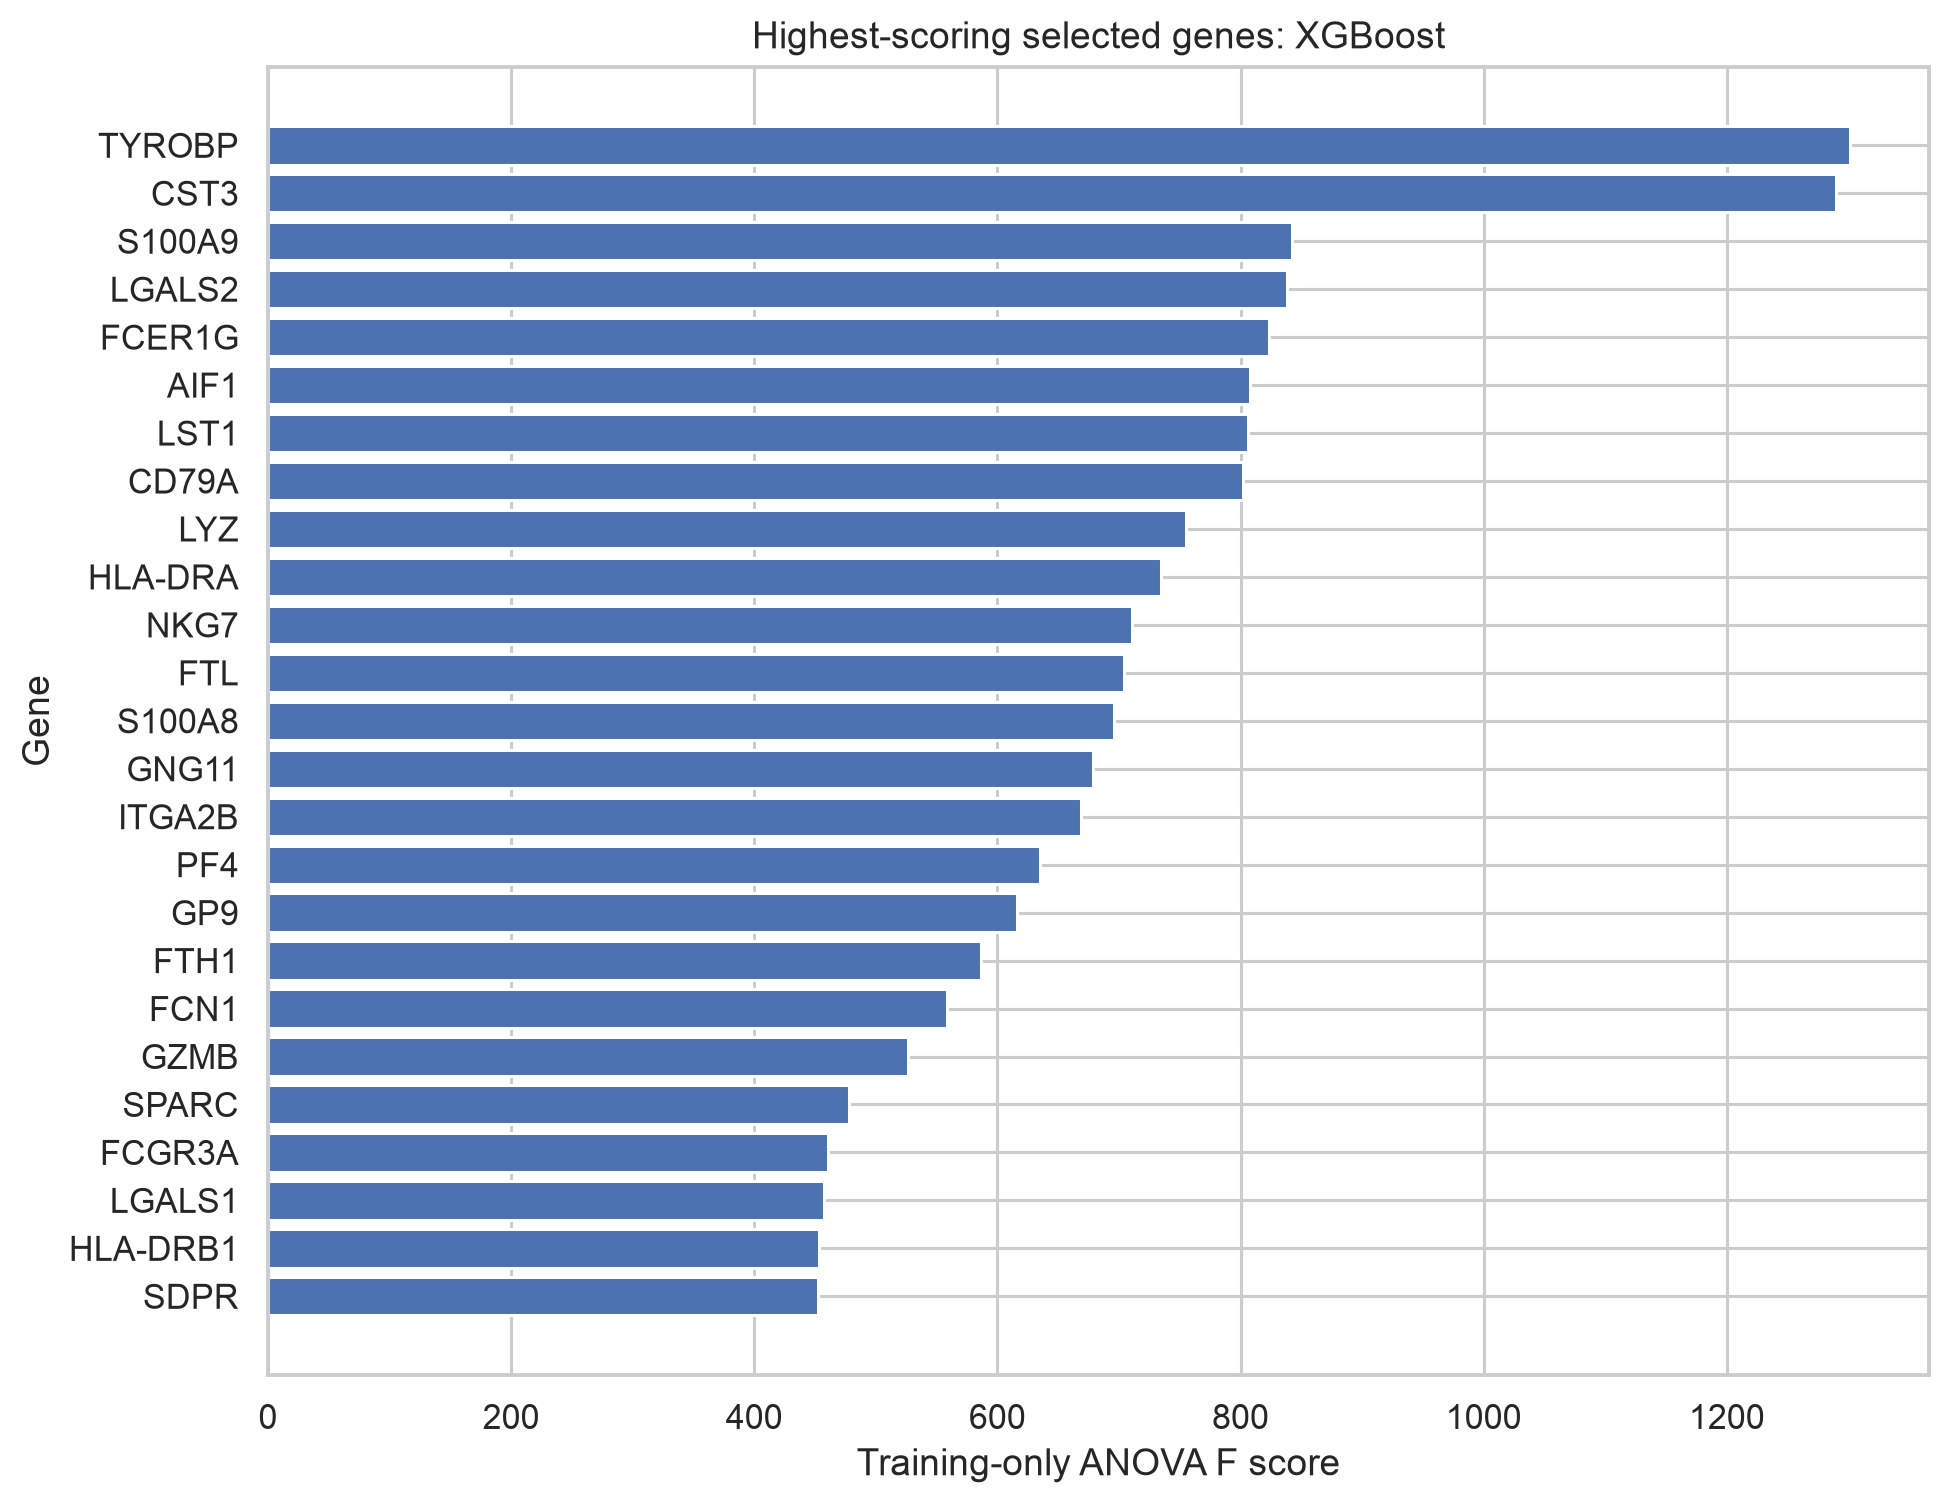

In [8]:
variance_mask = best_model.named_steps["variance"].get_support()
genes_after_variance = gene_names[variance_mask]
selected_mask_after_variance = best_model.named_steps["select"].get_support()
selected_genes = genes_after_variance[selected_mask_after_variance]
selected_f_scores = best_model.named_steps["select"].scores_[selected_mask_after_variance]
feature_score_table = pd.DataFrame({
    "gene": selected_genes,
    "training_f_score": selected_f_scores,
}).sort_values("training_f_score", ascending=False)
display(feature_score_table.head(25))

top_features = feature_score_table.head(25).sort_values("training_f_score")
plt.figure(figsize=(9, 7))
plt.barh(top_features["gene"], top_features["training_f_score"])
plt.xlabel("Training-only ANOVA F score")
plt.ylabel("Gene")
plt.title(f"Highest-scoring selected genes: {best_model_name}")
plt.tight_layout()
plt.show()

## 9. Save the comparison artifacts

The complete validation/test comparison table, winning model's untouched-test per-class report, and selected-gene score table are saved as CSV files. The fitted estimator is intentionally not serialized here because library-version changes can make pickle/joblib files unsafe or incompatible; the notebook and parameter table provide the reproducible training recipe.

In [9]:
comparison_path = TABLES / "classification_model_comparison.csv"
report_path = TABLES / "classification_best_model_per_class.csv"
feature_score_path = TABLES / "classification_selected_gene_scores.csv"

results_table.to_csv(comparison_path, index=True)
report.to_csv(report_path)
feature_score_table.to_csv(feature_score_path, index=False)

print("Best model:", best_model_name)
print("Saved:", comparison_path)
print("Saved:", report_path)
print("Saved:", feature_score_path)

Best model: XGBoost
Saved: /Users/brianqian/Desktop/cosmos/26-the-backpropagators-analysis/PBMC3k/results/tables/classification_model_comparison.csv
Saved: /Users/brianqian/Desktop/cosmos/26-the-backpropagators-analysis/PBMC3k/results/tables/classification_best_model_per_class.csv
Saved: /Users/brianqian/Desktop/cosmos/26-the-backpropagators-analysis/PBMC3k/results/tables/classification_selected_gene_scores.csv


## Final decision checklist

Before declaring the winner suitable for new data, confirm that:

- macro-F1 and per-class recall are acceptable, especially for rare populations;
- the confusion matrix does not hide systematic confusion between related T-cell or monocyte subtypes;
- performance is stable across biological donors, not merely random cells from one donor;
- normalization, gene identifiers, and feature ordering are identical for future samples;
- independent expert labels or orthogonal assays validate the target cell types;
- feature selection and hyperparameter tuning remain within training data, model-family selection remains within validation data, and test data remain untouched until final reporting.

Because PBMC3k contains one donor, this notebook estimates within-dataset reproducibility. Donor-level generalization requires additional independently processed donors and a group-aware train/test split.